In [12]:
import numpy as np
import pickle # 导入 pickle 模块
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append("./main_code")
import generate_data2,grid_cell,adaptive_int,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main,draw
CUDA_LAUNCH_BLOCKING=1
S_num_10=np.load("./Noise/noise=10%/S_num_0.0009999999999999998.npy")

cuda:3


In [13]:
def ana_S(y,x_left,x_right,y_below,y_upper,center,r): #总源
    cond1=(y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2<=r**2
    cond2=(y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2))*cond1+0.5*np.exp(-550*((y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2))*cond2

In [14]:
import pickle

with open("./Noise/noise=10%/cells_store_33.pkl", "rb") as f:
    cells_store=pickle.load(f)
x = np.linspace(-0.3, 0.3, 301)
y = np.linspace(-0.3, 0.3, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
S_num_10=np.load("./Noise/noise=10%/S_num_0.0009999999999999998.npy")
# 创建数据
S_num_store=np.load("./Noise/noise=10%/S_num_store.npy")

In [15]:
g_S=np.load("./Noise/noise=10%/g_S.npy")

Number of detected clusters: 2
Cluster 0: AR=1.03
  Res_Rect=0.077 vs Res_Ellip=0.071
  -> Winner: Circle
  CV of S_num: 0.730
Cluster 0: Lx=0.120, Ly=0.124, AR=1.03
  -> Decision: Circle (Exp)
  Center: (-0.060, 0.000)
    Radius: 0.064
    Rect Residual: 0.0772, Ellip Residual: 0.0713
    Aspect Ratio: 1.033
    Curvature - Std: 0.3721, Mean: 0.1480, Peak Ratio: 9.55
Cluster 1: AR=1.02
  Res_Rect=0.080 vs Res_Ellip=0.072
  -> Winner: Circle
  CV of S_num: 0.735
Cluster 1: Lx=0.122, Ly=0.124, AR=1.02
  -> Decision: Circle (Exp)
  Center: (0.081, -0.000)
    Radius: 0.065
    Rect Residual: 0.0797, Ellip Residual: 0.0719
    Aspect Ratio: 1.016
    Curvature - Std: 0.3677, Mean: 0.1439, Peak Ratio: 9.83


/mnt/store/hxw-y23/code/Ex4.4/./main_code/Bound_detect.py:440: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Created directory: ./results_ada/noise=10%_grad


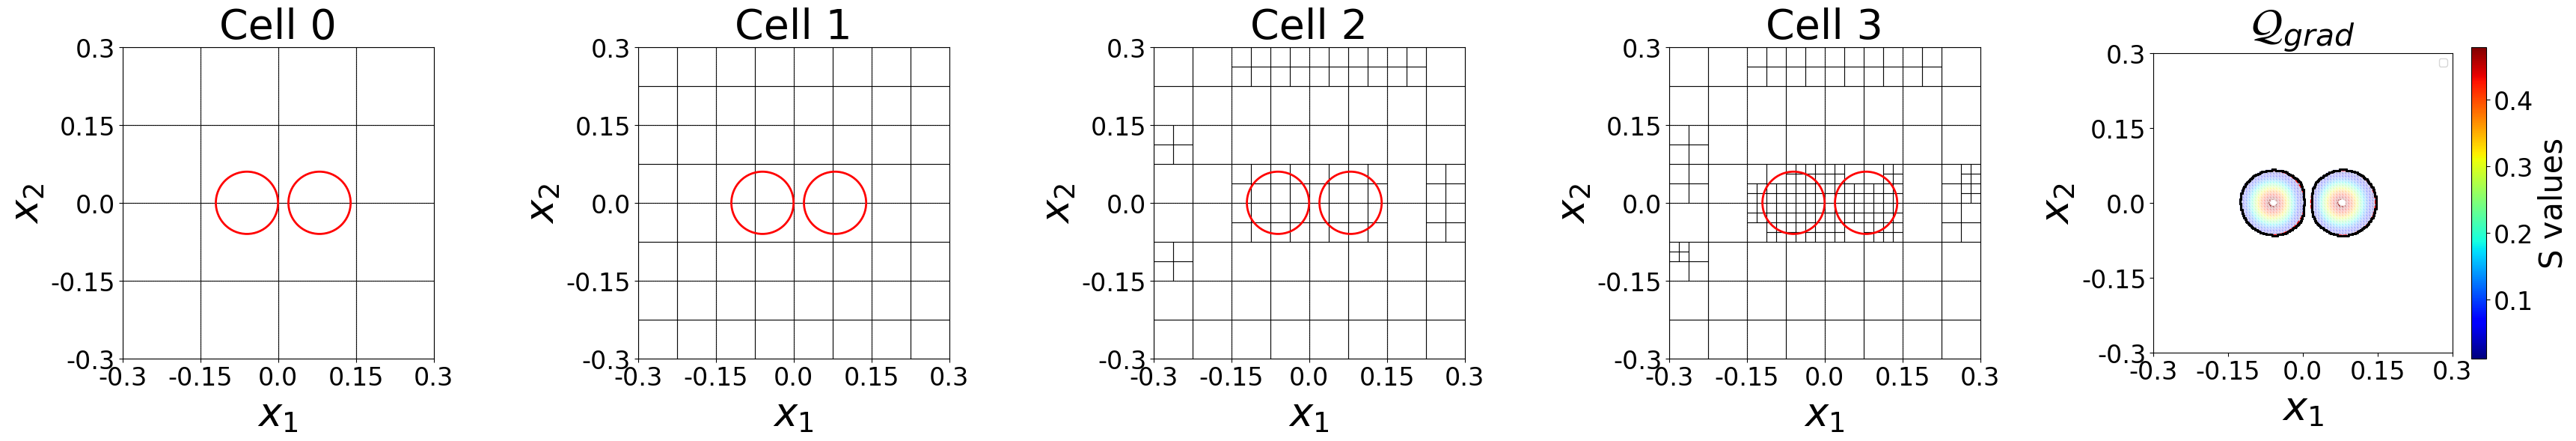

In [16]:
import gridlook
import Bound_detect
reload(Bound_detect)
reload(gridlook)
v=gridlook.MeshVisualizer()
fig=v.plot_mesh_evolution(cells_store[:-1], S_num_stores=S_num_store[-1], points=samples, save_path=None,label=True,g_S=g_S,temp=True)

In [17]:
fig.savefig("./Noise/noise=10%/mesh_evo_detect1.pdf", dpi=300, bbox_inches='tight')

In [18]:
reload(draw)

<module 'draw' from '/mnt/store/hxw-y23/code/Ex4.4/./main_code/draw.py'>

Plot saved as ./Noise/noise=10%/S_true.pdf


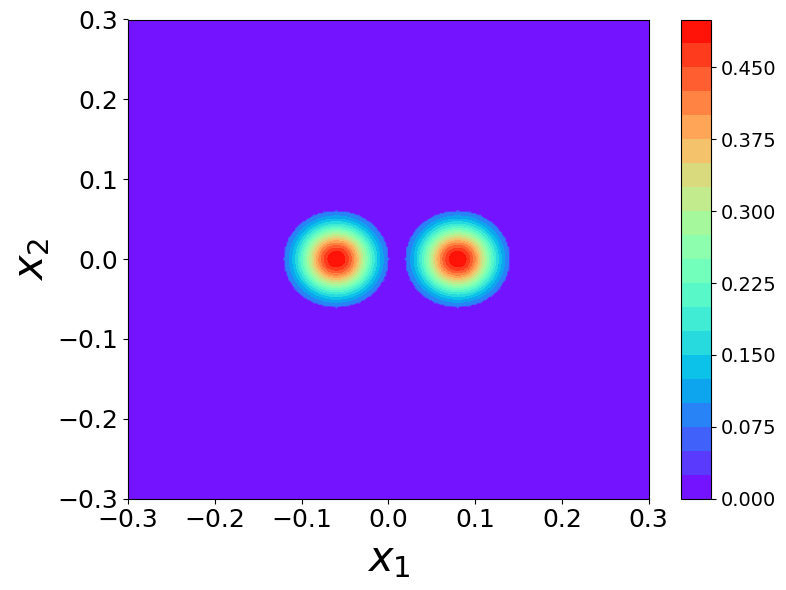

Plot saved as ./Noise/noise=10%/S_num_10.pdf


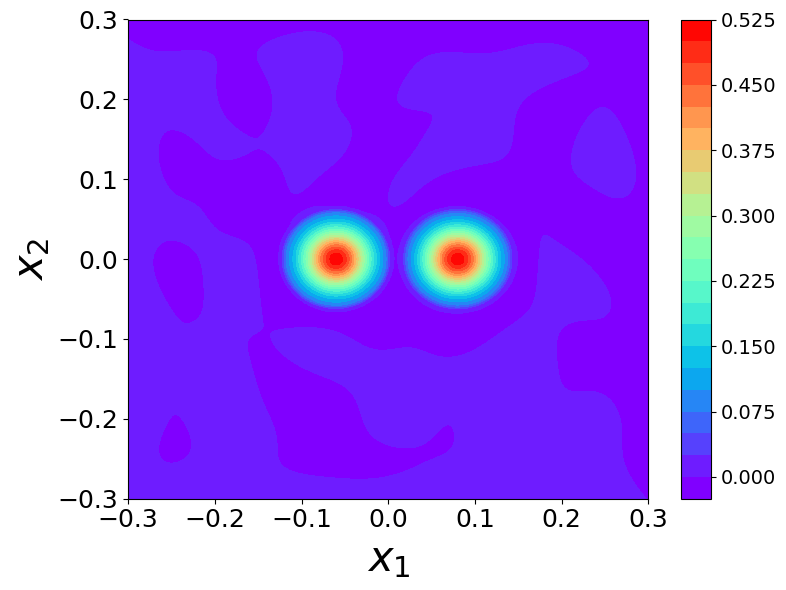

Plot saved as ./Noise/noise=10%/abs_S.pdf


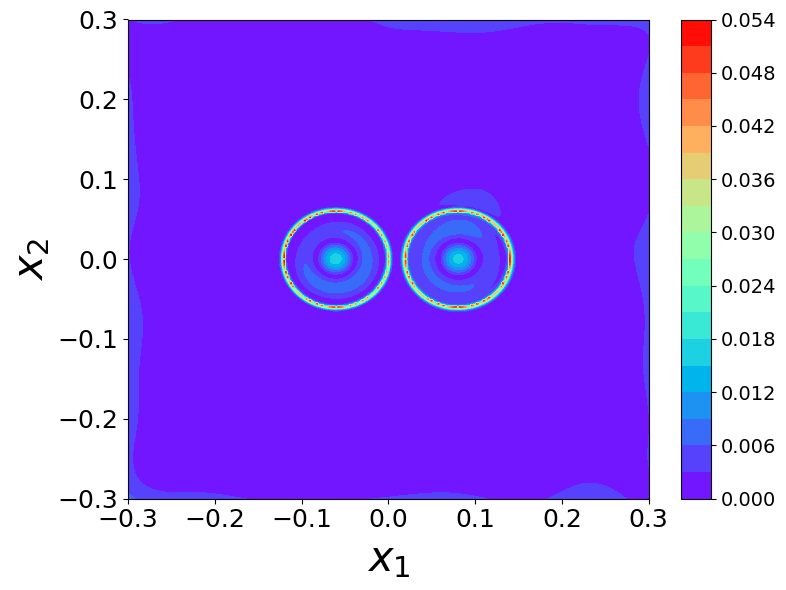

In [19]:
S_num_10=np.load("./Noise/noise=10%/S_num_0.0009999999999999998.npy")
# 创建数据
x = np.linspace(-0.3, 0.3, 301)
y = np.linspace(-0.3, 0.3, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
center=np.array([[-0.06,0],[0.08,0]])
r=0.06
S_true=ana_S(samples,[],[],[],[],center,r).reshape(len(x),len(y))
output_dictionary="./Noise/noise=10%"
draw.draw(X,Y,S_true,output_dictionary,"S_true.pdf")
draw.draw(X,Y,S_num_10,output_dictionary,"S_num_10.pdf")
draw.draw(X,Y,np.abs(S_true-S_num_10),output_dictionary,"abs_S.pdf")